In [38]:
# ── Stage 1: Load & Explore ──────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load directly from GitHub (no Kaggle login needed)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# ── Basic look ───────────────────────────────────────────────────────
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst 3 rows:\n", df.head(3))

Shape: (7043, 21)

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customer

/tmp/ipykernel_2202/1370240099.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='Set2')


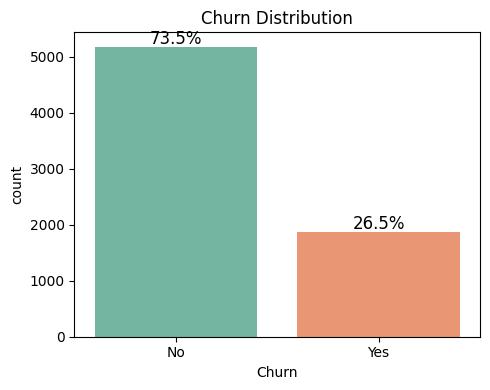

In [39]:
# ── Churn distribution ───────────────────────────────────────────────
plt.figure(figsize=(5, 4))
ax = sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')

# Add percentage labels on bars
total = len(df)
for p in ax.patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height() + 50),
                ha='center', fontsize=12)

plt.tight_layout()
plt.show()

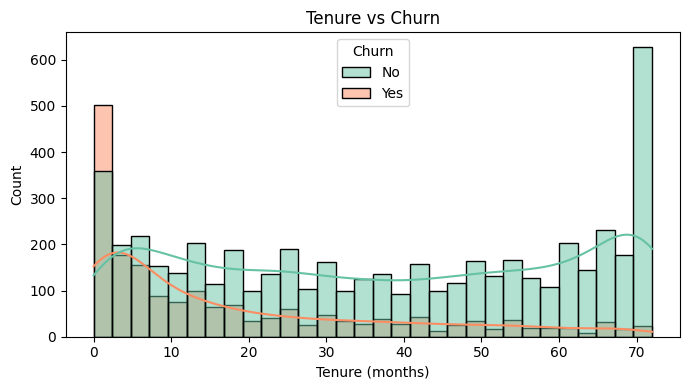

In [40]:
# ── Churn vs Tenure ──────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             kde=True, palette='Set2')
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (months)')
plt.tight_layout()
plt.show()

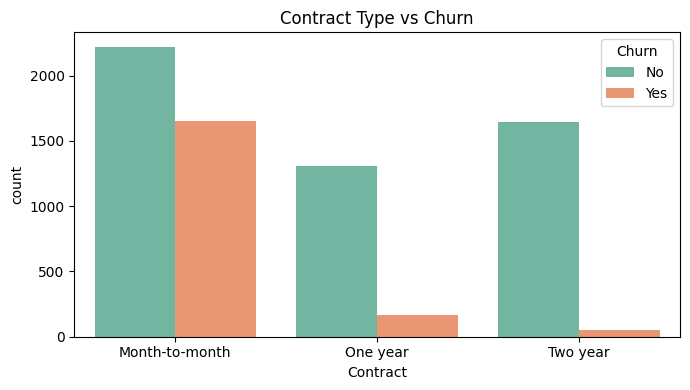

In [41]:
# ── Churn vs Contract Type ───────────────────────────────────────────
plt.figure(figsize=(7, 4))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Contract Type vs Churn')
plt.tight_layout()
plt.show()

In [42]:
# ── Stage 2: Preprocessing ───────────────────────────────────────────

# Step 1: Drop customerID (not useful for prediction)
df = df.drop(columns=['customerID'])

# Step 2: Fix TotalCharges — it's a string, convert to float
# Some rows have empty strings " " instead of NaN — this handles that
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaNs appeared after conversion
print("NaNs in TotalCharges after fix:", df['TotalCharges'].isnull().sum())

# Those rows have tenure=0 (brand new customers, no charges yet)
# Just fill them with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Step 3: Encode target column — Yes → 1, No → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("\nChurn value counts:\n", df['Churn'].value_counts())

NaNs in TotalCharges after fix: 11

Churn value counts:
 Churn
0    5174
1    1869
Name: count, dtype: int64


In [43]:
# Step 4: Separate categorical and numerical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('Churn')  # don't scale the target

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [44]:
# Step 5: One-Hot Encode all categorical columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("Sample columns:", df.columns.tolist()[:10])

Shape after encoding: (7043, 31)
Sample columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service']


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 6: Split features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Step 7: Train/Test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# stratify=y → keeps churn ratio same in both train and test splits

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("\nChurn ratio in train:", y_train.mean().round(3))
print("Churn ratio in test: ", y_test.mean().round(3))

X_train shape: (5634, 30)
X_test shape:  (1409, 30)

Churn ratio in train: 0.265
Churn ratio in test:  0.265


In [46]:
# Step 8: Scale numerical columns only
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# fit_transform on train → learns mean and std from training data only
# transform on test → applies same scale (no data leakage)

print("Preprocessing complete ✅")
print("Training samples:", X_train.shape[0])
print("Test samples:    ", X_test.shape[0])

Preprocessing complete ✅
Training samples: 5634
Test samples:     1409


In [47]:
# ── Stage 3: Train & Compare Models ──────────────────────────────────

!pip install xgboost -q

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "AdaBoost":            AdaBoostClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(
                               n_estimators=100,
                               learning_rate=0.1,
                               max_depth=4,
                               eval_metric='logloss',
                               random_state=42
                           )
}

In [48]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(report['1']['precision'], 3),
        "Recall":    round(report['1']['recall'], 3),
        "F1-Score":  round(report['1']['f1-score'], 3)
    })

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


  Decision Tree
              precision    recall  f1-score   support

    No Churn       0.81      0.81      0.81      1035
       Churn       0.48      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.72      0.73      0.72      1409


  AdaBoost
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.7

In [49]:
# ── Summary comparison table ──────────────────────────────────────────
results_df = pd.DataFrame(results).set_index("Model")
print("\n📊 Model Comparison (on Churn class):")
print(results_df.to_string())


📊 Model Comparison (on Churn class):
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression     0.807      0.660   0.561     0.607
Decision Tree           0.725      0.482   0.479     0.481
AdaBoost                0.804      0.668   0.521     0.586
XGBoost                 0.801      0.656   0.524     0.582


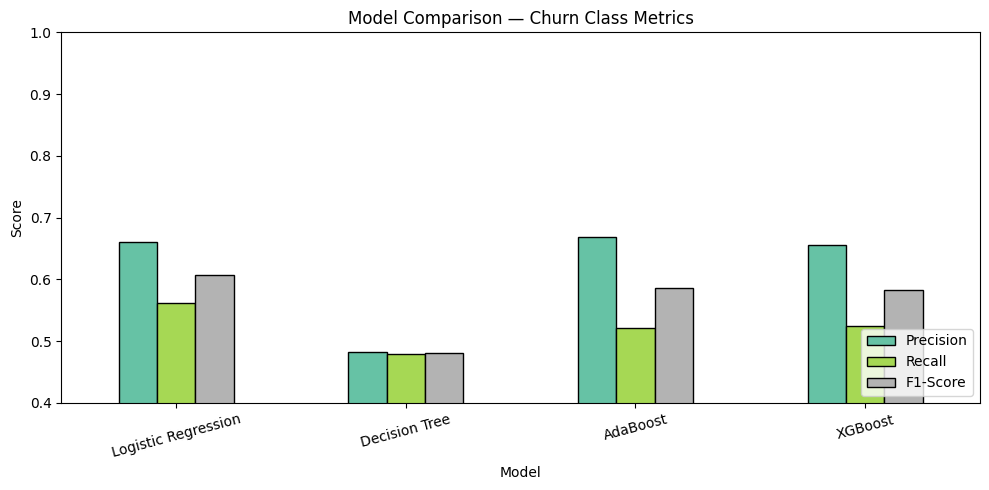

In [50]:
# ── Bar chart ─────────────────────────────────────────────────────────
results_df[['Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black'
)
plt.title('Model Comparison — Churn Class Metrics')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.4, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [51]:
# ── Save best model reference for Stage 4 ────────────────────────────
best_model = models["XGBoost"]
print("Best model saved ✅")

Best model saved ✅


In [52]:
!pip install shap==0.44.1 numpy==1.26.4 -q

In [53]:
# ── Stage 4: SHAP Explainability ─────────────────────────────────────

import shap
import matplotlib.pyplot as plt

best_model = models["Logistic Regression"]

# Convert to numpy explicitly to avoid type conflict
X_train_np = X_train.values
X_test_np  = X_test.values

explainer  = shap.LinearExplainer(best_model, X_train_np)
shap_vals  = explainer.shap_values(X_test_np)

print("SHAP values shape:", shap_vals.shape)
print("SHAP ready ✅")

SHAP values shape: (1409, 30)
SHAP ready ✅


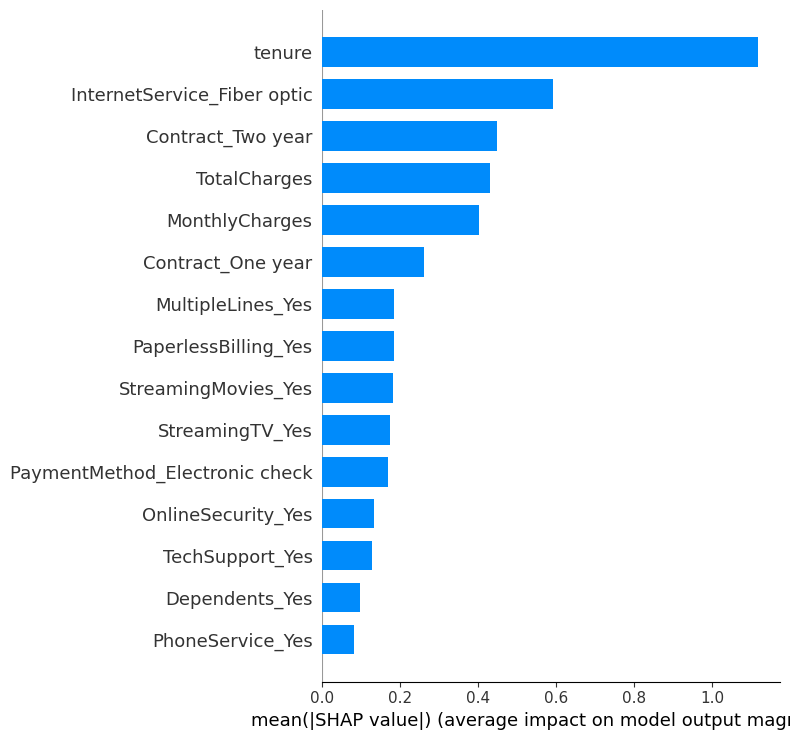

In [54]:
# ── Plot 1: Bar (global importance) ───────────────────────────────────

shap.summary_plot(shap_vals, X_test_np,
                  feature_names=X_test.columns.tolist(),
                  plot_type="bar", max_display=15)

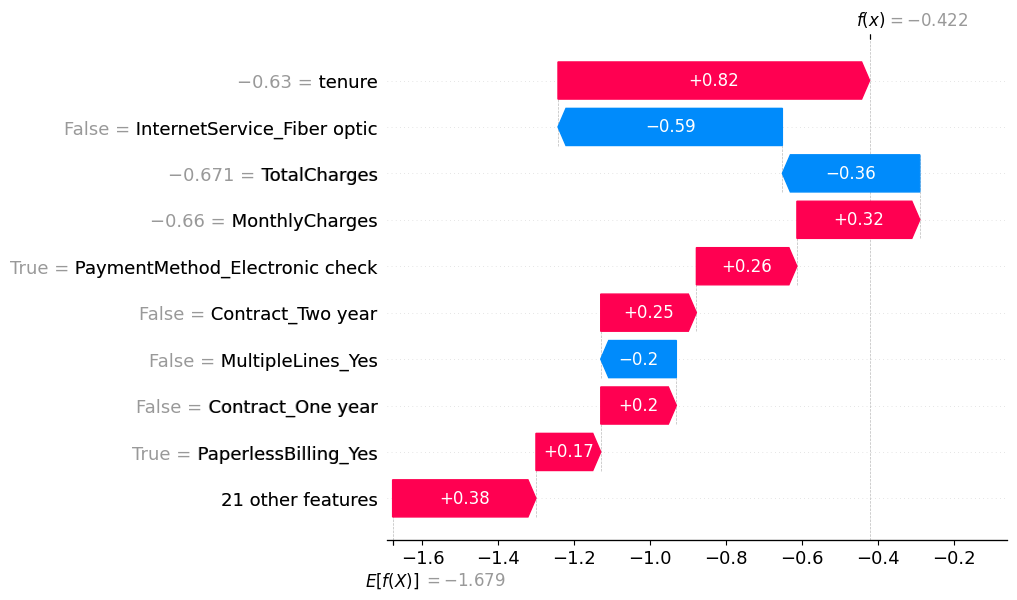

In [55]:
# ── Plot 2: Single churned customer waterfall ─────────────────────────

churn_indices = y_test[y_test == 1].index.tolist()
sample_idx    = X_test.index.get_loc(churn_indices[0])

shap.waterfall_plot(
    shap.Explanation(
        values       = shap_vals[sample_idx],
        base_values  = explainer.expected_value,
        data         = X_test_np[sample_idx],
        feature_names= X_test.columns.tolist()
    )
)

In [56]:
# ── Save model and scaler ─────────────────────────────────────────────

import pickle
from google.colab import files

# Save model
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature column names (needed to align input in the app)
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

# Download all 3 to your computer
files.download('model.pkl')
files.download('scaler.pkl')
files.download('feature_columns.pkl')

print("All files saved and downloaded ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files saved and downloaded ✅
